# Portfolio Optimization with proportional transaction costs

Consider the Merton problem with proportional transaction costs. That means that a purchase or sale of  $\xi$ stocks incurs transaction costs $\lambda|\xi|S_t$  where we set $\lambda=0.01$.

For this purpose we parametrize the strategy additively, i.e. we choose a neural network which outputs the number of shares to be held. Notice the contrast to the friction-free setting, where a multiplicative parametrization is chosen.

In [ ]:
import numpy as np
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Concatenate, Dropout, Subtract, \
                        Flatten, MaxPooling2D, Multiply, Lambda, Add, Dot
from keras.backend import constant
from keras import optimizers

from keras.engine.topology import Layer
from keras.models import Model
from keras.layers import Input
from keras import initializers
from keras.constraints import max_norm
import keras.backend as K

import matplotlib.pyplot as plt

Using TensorFlow backend.

Bad key "text.kerning_factor" on line 4 in
/usr/share/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
http://github.com/matplotlib/matplotlib/blob/master/matplotlibrc.template
or from the matplotlib source distribution

Bad key "lines.markerfacecolor" on line 11 in
/usr/share/matplotlib/mpl-data/stylelib/classic.mplstyle.
You probably need to get an updated matplotlibrc file from
http://github.com/matplotlib/matplotlib/blob/master/matplotlibrc.template
or from the matplotlib source distribution

Bad key "lines.markeredgecolor" on line 12 in
/usr/share/matplotlib/mpl-data/stylelib/classic.mplstyle.
You probably need to get an updated matplotlibrc file from
http://github.com/matplotlib/matplotlib/blob/master/matplotlibrc.template
or from the matplotlib source distribution


In [ ]:
# Trajectories of the Black scholes model
# Let it run to initialize the following parameters, the trajectories
# are not needed afterwards

N=60 # time disrectization
S0=1 # initial value of the asset
X0=1  # initial wealth
T=1 # maturity
sigma=0.2 # volatility in Black Scholes
mu=0.1
r=0.0
gamma=0.1
R=10000 # number of Trajectories

logS= np.zeros((N,R))
logS[0,]=np.log(S0)*np.ones((1,R))

for i in range(R):
    for j in range(N-1):
        increment = np.random.normal(mu*T/N-sigma**2/2*T/N,sigma*np.sqrt(T)/np.sqrt(N))
        logS[j+1,i] =logS[j,i]+increment

S=np.exp(logS)

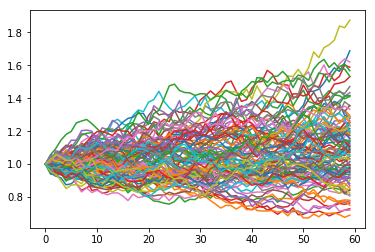

In [ ]:
for i in range(100):
   plt.plot(S[:,i])
plt.show()

In [ ]:
# True alpha without transaction costs

logX= np.zeros((N,R))
logX[0,]=np.log(X0)*np.ones((1,R))
alpha= (mu-r)/(sigma**2*(1-gamma)) #Merton ratio

In [ ]:
# Calculating the loss with the true alpha - W^{\gamma}

for i in range(R):
    for j in range(N-1):
        increment = np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N))
        logX[j+1,i] =logX[j,i]+increment*alpha+r*T/N*(1-alpha)-alpha**2*sigma**2*T/(2*N) #log wealth

X=np.exp(logX)
loss=np.mean(-((X[N-1,:]**gamma)-1)/gamma)
print(loss)

-0.14035850750905265


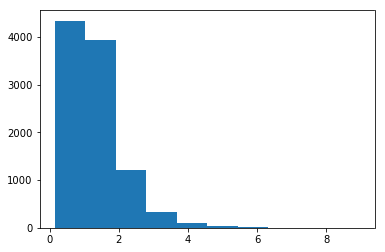

1.317884396375772
0.7816186604927835


In [ ]:
plt.hist(X[N-1,:])
plt.show()
print(np.mean(X[N-1,:]))
print(np.std(X[N-1,:]))

In [ ]:
#Definition of neural networks for heding strategies

m = 1 # dimension of price
d = 3 # number of layers in strategy
n = 16  # nodes in the first but last layers

# architecture is the same for all networks
layers = []
for j in range(N):
    for i in range(d):
        if i < d-1:
            nodes = n
            layer = Dense(nodes, activation='tanh',trainable=True,
                      kernel_initializer=initializers.RandomNormal(.0,.3),#kernel_initializer='random_normal',
                      bias_initializer=initializers.RandomNormal(.0,.3),
                      name=str(i)+str(j))
        else:
            nodes = m
            layer = Dense(nodes, activation='linear', trainable=True,
                          kernel_initializer=initializers.RandomNormal(.0,.3),#kernel_initializer='random_normal',
                          bias_initializer=initializers.RandomNormal(.0,.3),
                          name=str(i)+str(j))
        layers = layers + [layer]

In [ ]:
#Implementing the loss function
# Inputs is the training set below, containing the price S0,
#the initial trade being 0, and dummy variables tradeeval where the strategies are evaluated, the initial wealth
#and the increments of the log price process
price = Input(shape=(m,))
trade = Input(shape=(m,))
tradeeval = Input(shape=(m,))
tradeevalstrat = Input(shape=(m,))
wealth = Input(shape=(1,))
costs = Input(shape=(1,))

inputs = [price]+[trade]+[tradeeval]+[tradeevalstrat]+[wealth]+[costs]
outputhelper=[]

for j in range(N):
    strategy =  Concatenate()([wealth, trade])
    strategyeval= Concatenate()([tradeeval, tradeevalstrat])
    for k in range(d):
        strategy= layers[k+(j)*d](strategy) # strategy at j is the alpha at j
        strategyeval=layers[k+(j)*d](strategyeval)
    incr = Input(shape=(m,)) # log price increments
    logprice= Lambda(lambda x : K.log(x))(price)
    logprice = Add()([logprice, incr])
    logprice = Lambda(lambda x : x - sigma**2/2.*T/N)(logprice)
    pricenew=Lambda(lambda x : K.exp(x))(logprice)

    increment = Subtract()([pricenew,price])
    helper1 = Multiply()([increment,strategy])
    wealthnew = Add()([helper1,wealth])

    change = Subtract()([strategy,trade])
    absolutechanges = Lambda(lambda x : K.abs(x))(change)
    costshelper = Multiply()([absolutechanges,price])
    costshelper = Lambda(lambda x : -0.01*x)(costshelper)
    costs = Add()([costs,costshelper])
    trade=strategy
    price=pricenew
    wealth = wealthnew
    inputs = inputs + [incr]
    outputhelper = outputhelper + [strategyeval] # here we collect the strategies
absolutechanges = Lambda(lambda x : K.abs(x))(trade)
costshelper = Multiply()([absolutechanges,price])
costshelper = Lambda(lambda x : -0.01*x)(costshelper)
costs = Add()([costs,costshelper])
outputs = Add()([costs,wealth])
outputs = [outputs] + outputhelper
outputs = Concatenate()(outputs)


model_Merton = Model(inputs=inputs, outputs=outputs)

In [ ]:
Ktrain = 10**5
initialprice = S0
initialwealth = X0
# xtrain consists of the price S0,
#the initial hedging being 0, and dummy variables hedgeeval where the strategies are evaluated,
#the initial wealth and the increments of the log price process
xtrain = ([initialprice*np.ones((Ktrain,m))] +
          [np.zeros((Ktrain,m))]+
          [1*np.ones((Ktrain,m))] +
          [1*np.ones((Ktrain,m))]+
          [initialwealth*np.ones((Ktrain,m))] +
          [np.zeros((Ktrain,m))]+
          [np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N),(Ktrain,m)) for i in range(N)])

ytrain=np.zeros((Ktrain,1+N))

In [ ]:

def custom_loss(y_true,y_pred):
    z = -(((K.relu(y_pred[:,0])+10**(-7))**gamma)-1)/gamma
    #z = - K.log(K.relu(y_pred[:,0])+10**(-7))
    #z = K.exp(-y_pred[:,0])
    z=K.mean(z)
    return z

In [ ]:
from keras import optimizers

adam=optimizers.Adam(lr=0.01)#, beta_1=0.9, beta_2=0.999)

model_Merton.compile(optimizer='adam',loss=custom_loss)

In [ ]:
import matplotlib.pyplot as plt

for i in range(1):
    model_Merton.fit(x=xtrain,y=ytrain, epochs=10,verbose=True,batch_size=100)


Epoch 1/10
100000/100000 [==============================] - 52s - loss: 0.0054    
Epoch 2/10
100000/100000 [==============================] - 39s - loss: 0.0019    
Epoch 3/10
100000/100000 [==============================] - 36s - loss: 0.0017    
Epoch 4/10
100000/100000 [==============================] - 35s - loss: 0.0016    
Epoch 5/10
100000/100000 [==============================] - 35s - loss: 0.0015    
Epoch 6/10
100000/100000 [==============================] - 36s - loss: 0.0014    
Epoch 7/10
100000/100000 [==============================] - 42s - loss: 0.0014    
Epoch 8/10
100000/100000 [==============================] - 36s - loss: 0.0014    
Epoch 9/10
100000/100000 [==============================] - 40s - loss: 0.0013    
Epoch 10/10
100000/100000 [==============================] - 37s - loss: 0.0013    


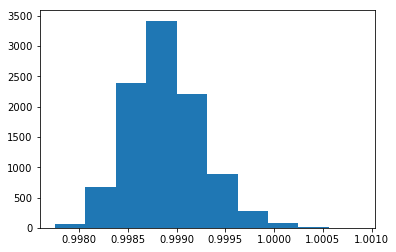

0.99888563
0.00037690141


In [ ]:
Ktest = 10**4
initialprice = S0
initialwealth = X0
# xtrain consists of the price S0,
#the initial hedging being 0, and dummy variables hedgeeval where the strategies are evaluated,
#the initial wealth and the increments of the log price process
xtest = ([initialprice*np.ones((Ktest,m))] +
          [np.zeros((Ktest,m))]+
          [1*np.ones((Ktest,m))] +
          [1*np.ones((Ktest,m))]+
          [initialwealth*np.ones((Ktest,m))] +
          [np.zeros((Ktest,m))]+
          [np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N),(Ktest,m)) for i in range(N)])

x = model_Merton.predict(xtest)[:,0]
plt.hist(x)
plt.show()
print(np.mean(x))
print(np.std(x))

In [ ]:

Ktest=60
xtest = ([initialprice*np.ones((Ktest,m))] +
          [np.zeros((Ktest,m))]+
          [np.linspace(0.7,1.3,Ktest)] +#change this if you go to higher dimensions
          [1.0*alpha*np.ones((Ktest,m))]+
          [initialwealth*np.ones((Ktest,m))]+
          [np.zeros((Ktest,m))]+
          [np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N),(Ktest,m)) for i in range(N)])

learnedstrat=model_Merton.predict(xtest)[:,1:N-1]


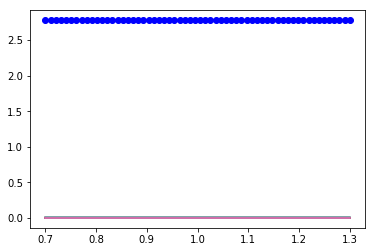

In [ ]:
#learned alpha


s=np.linspace(.7,1.3,Ktest)


truestrat=(mu-r)/(sigma**2*(1-gamma))*np.ones(Ktest) # without transaction costs
plt.plot(s,learnedstrat[:,0:27], s, truestrat,'bo-')

plt.show()